# Week 4 — Deterministic & Multi-Objective MILP Block Scheduling


### Objectives
1. Formulate the block-sequencing MILP (binary `y[block, period]`)
2. Solve the **NPV-only** deterministic problem with PuLP / CBC
3. Build the **NPV vs Throughput** Pareto frontier via ε-constraint
4. Add a **third objective** (strip ratio) for a genuine 3-objective analysis
5. Summarise results in a KPI table with operational interpretation

### Mathematical Foundation

Let:
- $B$ = set of blocks $\{0, \ldots, N-1\}$, $\;T$ = set of periods $\{1, \ldots, 10\}$
- $y_{b,t} \in \{0,1\}$ = 1 if block $b$ is mined in period $t$
- $\delta_t = (1+r)^{-t}$ = discount factor, $r = 10\%$
- $v_b$ = expected NPV of block $b$ (from Week 2 Monte Carlo, \$M)
- $\tau_b$ = tonnage of block $b$ (kt)
- $g_b$ = ore grade of block $b$ (fraction)
- $\text{SR}_b$ = strip ratio of block $b$

**Objective — maximise discounted NPV:**
$$\max \; Z_{NPV} = \sum_{t=1}^{T} \delta_t \sum_{b \in B} v_b \, y_{b,t}$$

**Subject to:**

*Each block mined exactly once:*
$$\sum_{t=1}^{T} y_{b,t} = 1 \quad \forall b \in B$$

*Mining-capacity bounds (kt):*
$$\underline{MC} \leq \sum_{b} \tau_b \, y_{b,t} \leq \overline{MC} \quad \forall t$$

*Processing-capacity bounds — throughput (kt ore):*
$$\underline{PC} \leq \sum_{b} \tau_b \, g_b \, y_{b,t} / \bar{g} \leq \overline{PC} \quad \forall t$$

*Slope / precedence — predecessor block $p$ of block $b$ must be mined before or in the same period:*
$$\underline{PC} \leq \sum_{b} \tau_b \cdot O_b \cdot y_{b,t} \leq \overline{PC} \quad \forall t$$

**Two-objective ε-constraint**

Fix a minimum throughput level $\varepsilon_k$ and maximise NPV:
$$\max Z_{NPV} \quad \text{s.t.} \quad \sum_{t=1}^{T} \sum_{b} \tau_b \cdot O_b \cdot y_{b,t} \geq \varepsilon_k$$

Sweeping $\varepsilon_k$ traces the **NPV–Throughput Pareto frontier**.

**Third objective — minimise discounted strip ratio:**
$$\min \; Z_{SR} = \sum_{t} \delta_t \sum_{b} \text{SR}_b \, \tau_b \, y_{b,t}$$

Added as a second ε-constraint for the 3-objective Pareto surface.

## 0. Imports & Configuration

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
import warnings, time, os
warnings.filterwarnings('ignore')

import pulp
from pulp import lpSum, LpVariable, LpProblem, LpMaximize, LpMinimize, LpStatus, value

np.random.seed(42)
print('PuLP version :', pulp.__version__)
print('Solvers available:', pulp.listSolvers(onlyAvailable=True))

#Constants
T              = 10          # scheduling periods
DISCOUNT_RATE  = 0.10        # 10 % annual discount rate
CAPACITY_LO    = 0.70        # lower bound = 70% of average period tonnage
CAPACITY_HI    = 1.30        # upper bound = 130% of average period tonnage
PROC_LO        = 0.70        # processing lower bound fraction
PROC_HI        = 1.30        # processing upper bound fraction
GRADE_CUTOFF   = 0.50        # ore/waste cutoff grade (fraction)
N_PARETO_PTS   = 15          # number of ε-constraint sweep points
SOLVER_TIME_LIM = 120        # seconds per MILP solve

print(f'\nConfiguration: T={T}, r={DISCOUNT_RATE:.0%}, '
      f'capacity [{CAPACITY_LO:.0%}, {CAPACITY_HI:.0%}], '
      f'Pareto points={N_PARETO_PTS}')


PuLP version : 3.3.1
Solvers available: ['PULP_CBC_CMD']

Configuration: T=10, r=10%, capacity [70%, 130%], Pareto points=15


## 1. Load Data (from Weeks 2 & 3)

In [4]:
#Load block model with Monte Carlo NPV estimates 
df = pd.read_csv('block_model_with_simulation.csv')
print(f'Block model : {df.shape[0]} blocks × {df.shape[1]} columns')

mc = np.load('monte_carlo_matrices.npz')
grade_matrix = mc['grade_matrix']
npv_matrix   = mc['npv_matrix']  
print(f'Monte Carlo : {grade_matrix.shape[1]} scenarios per block')


blocks        = df['block_id'].tolist()
N             = len(blocks)
b_idx         = {bid: i for i, bid in enumerate(blocks)}

tonnage       = df['tonnage_kt'].values          # kt
grade         = df['ore_grade_pct'].values        # fraction
strip_ratio   = df['stripping_ratio'].values      # t waste / t ore
npv_exp       = df['npv_expected'].values / 1e6   # $M
npv_std       = df['npv_std'].values / 1e6        # $M  (for risk annotations)
z_level       = df['z'].values                    # bench elevation (m)
slope_sc      = df['slope_constraint'].values  
x_coord       = df['x'].values
y_coord       = df['y'].values

# Discount factors 
disc = np.array([1/(1+DISCOUNT_RATE)**t for t in range(1, T+1)])

#Capacity bounds 
avg_tonnage   = tonnage.sum() / T
MC_lo         = CAPACITY_LO * avg_tonnage
MC_hi         = CAPACITY_HI * avg_tonnage

# Create binary indicator for blocks meeting the cut-off grade
ore_indicator = np.where(grade >= GRADE_CUTOFF, 1, 0)

# Throughput is now physical ore tonnage
avg_throughput = (tonnage * ore_indicator).sum() / T
PC_lo          = PROC_LO  * avg_throughput
PC_hi          = PROC_HI  * avg_throughput

print(f'\nCapacity bounds  : [{MC_lo:,.0f}, {MC_hi:,.0f}] kt/period')
print(f'Throughput bounds: [{PC_lo:,.0f}, {PC_hi:,.0f}] kt ore/period')
print(f'Total NPV (undiscounted, expected): ${npv_exp.sum():.1f} M')


Block model : 500 blocks × 18 columns
Monte Carlo : 200 scenarios per block

Capacity bounds  : [17,578, 32,645] kt/period
Throughput bounds: [17,413, 32,338] kt ore/period
Total NPV (undiscounted, expected): $17036.3 M


## 2. Build Precedence Constraints

### Slope Precedence Rule

A block at depth $z$ may only be mined **after all predecessor blocks at $z + 10\,\text{m}$**
within a lateral radius $R = \text{slope\_constraint} \times 50\,\text{m}$ have been mined.

This encodes the open-pit wall-angle constraint:
$$\text{slope\_constraint} = 1 \Rightarrow 50\,\text{m radius};\quad
   \text{slope\_constraint} = 3 \Rightarrow 150\,\text{m radius}$$


In [5]:
BENCH_STEP = 10   # z spacing (m)
XY_STEP    = 50   # x,y grid spacing (m)

def build_precedence(df, bench_step=BENCH_STEP, xy_step=XY_STEP):
    """
    Returns dict: block_id -> [list of predecessor block_ids that must be
    mined in period ≤ t for block b to be mined in period t].
    """
    prec = {}
    for i, row in df.iterrows():
        b_id    = row['block_id']
        z_b     = row['z']
        x_b, y_b = row['x'], row['y']
        radius  = row['slope_constraint'] * xy_step   # lateral reach
        z_above = z_b + bench_step

        preds = df[
            (df['z'] == z_above) &
            (np.abs(df['x'] - x_b) <= radius) &
            (np.abs(df['y'] - y_b) <= radius)
        ]['block_id'].tolist()
        prec[b_id] = preds

    n_with  = sum(1 for v in prec.values() if v)
    avg_cnt = np.mean([len(v) for v in prec.values()])
    print(f'Precedence built: {n_with}/{len(df)} blocks have ≥1 predecessor '
          f'(mean {avg_cnt:.1f} predecessors/block)')
    return prec

prec = build_precedence(df)

# Count total precedence pairs (= number of slope constraints in MILP)
total_pairs = sum(len(v) for v in prec.values())
print(f'Total precedence pairs: {total_pairs:,}')
print(f'Example — B0000 predecessors: {prec["B0000"]}')


Precedence built: 388/500 blocks have ≥1 predecessor (mean 2.7 predecessors/block)
Total precedence pairs: 1,327
Example — B0000 predecessors: ['B0005', 'B0035', 'B0328', 'B0435', 'B0487']


## 3.NPV-Only MILP (Deterministic)

We first solve the single-objective NPV-maximisation problem.
This gives the **upper bound** on NPV and the reference schedule.


In [6]:
def solve_npv_only(blocks, N, tonnage, grade,ore_indicator, npv_exp, disc,
                   prec, b_idx, T, MC_lo, MC_hi, PC_lo, PC_hi,
                   time_limit=SOLVER_TIME_LIM, verbose=False):
    """
    Solve NPV-only open-pit block scheduling MILP.

    Decision variable:  y[b, t] ∈ {0,1}
    Objective:          max Σ_t δ_t Σ_b npv_b · y[b,t]

    Returns: (status, obj_value_$M, schedule_df, solve_time_s)
    """
    prob = LpProblem('NPV_Only_MILP', LpMaximize)

    #Decision variables
    y = LpVariable.dicts('y',
                         [(b, t) for b in blocks for t in range(1, T+1)],
                         cat='Binary')

    #Objective 
    prob += lpSum(disc[t-1] * npv_exp[b_idx[b]] * y[b, t]
                  for b in blocks for t in range(1, T+1)), 'Discounted_NPV'

    #C1: Each block mined exactly once 
    for b in blocks:
        prob += lpSum(y[b, t] for t in range(1, T+1)) == 1, f'once_{b}'

    #C2: Mining capacity per period
    for t in range(1, T+1):
        mine_vol = lpSum(tonnage[b_idx[b]] * y[b, t] for b in blocks)
        prob += mine_vol >= MC_lo, f'mc_lo_{t}'
        prob += mine_vol <= MC_hi, f'mc_hi_{t}'

    #C3: Processing / throughput capacity per period 
    for t in range(1, T+1):
        # Multiply by ore_indicator instead of grade
        throughput = lpSum(tonnage[b_idx[b]] * ore_indicator[b_idx[b]] * y[b, t]
                           for b in blocks)
        prob += throughput >= PC_lo, f'pc_lo_{t}'
        prob += throughput <= PC_hi, f'pc_hi_{t}'

    # C4: Slope / precedence constraints
    for b in blocks:
        i = b_idx[b]
        for p in prec.get(b, []):
            j = b_idx[p]
            for t in range(1, T+1):
                # Σ_{t'≤t} y[p,t'] >= Σ_{t'≤t} y[b,t']
                prob += (lpSum(y[p, t_] for t_ in range(1, t+1)) >=
                         lpSum(y[b, t_] for t_ in range(1, t+1))),                         f'prec_{b}_{p}_{t}'

    #Solve
    solver = pulp.PULP_CBC_CMD(msg=int(verbose), timeLimit=time_limit,
                               options=['--ratio', '0.01'])   # 1% MIP gap
    t0 = time.time()
    prob.solve(solver)
    elapsed = time.time() - t0

    status = LpStatus[prob.status]
    obj    = value(prob.objective) if prob.status == 1 else None

    #Extract schedule
    sched = []
    for b in blocks:
        for t in range(1, T+1):
            if value(y[b, t]) is not None and value(y[b, t]) > 0.5:
                i = b_idx[b]
                sched.append({
                    'block_id' : b,
                    'period'   : t,
                    'tonnage'  : tonnage[i],
                    'grade'    : grade[i],
                    'npv_exp'  : npv_exp[i],
                    'strip_ratio': strip_ratio[i],
                    'disc_npv' : disc[t-1] * npv_exp[i],
                    'throughput': tonnage[i] * ore_indicator[i],
                })
    sched_df = pd.DataFrame(sched)

    return status, obj, sched_df, elapsed

print('Solving NPV-only MILP (500 blocks, 10 periods) …')
print('  This may take 1–3 minutes with CBC (1% MIP-gap stopping criterion)')
status_npv, obj_npv, sched_npv, t_npv = solve_npv_only(
    blocks, N, tonnage, grade, ore_indicator,npv_exp, disc,
    prec, b_idx, T, MC_lo, MC_hi, PC_lo, PC_hi
)
print(f'  Status      : {status_npv}')
print(f'  Discounted NPV : ${obj_npv:.2f} M')
print(f'  Solve time  : {t_npv:.1f} s')


Solving NPV-only MILP (500 blocks, 10 periods) …
  This may take 1–3 minutes with CBC (1% MIP-gap stopping criterion)
  Status      : Optimal
  Discounted NPV : $11436.24 M
  Solve time  : 126.4 s


## 4. NPV-Only Schedule — Per-Period Analysis

In [7]:
#Per-period KPIs 
period_kpi = sched_npv.groupby('period').agg(
    n_blocks    = ('block_id',   'count'),
    tonnage_kt  = ('tonnage',    'sum'),
    throughput  = ('throughput', 'sum'),
    disc_npv_M  = ('disc_npv',   'sum'),
    avg_grade   = ('grade',      'mean'),
    avg_sr      = ('strip_ratio','mean'),
).reset_index()

period_kpi['cum_disc_npv_M'] = period_kpi['disc_npv_M'].cumsum()
period_kpi['util_pct']       = period_kpi['tonnage_kt'] / MC_hi * 100

print('NPV-Only Schedule — Per-Period KPIs')
print('=' * 85)
print(period_kpi.to_string(index=False, float_format=lambda x: f'{x:,.1f}'))
print('=' * 85)
print(f'Total discounted NPV: ${period_kpi["disc_npv_M"].sum():.2f} M')
print(f'Total throughput    : {period_kpi["throughput"].sum():,.0f} kt·grade')


NPV-Only Schedule — Per-Period KPIs
 period  n_blocks  tonnage_kt  throughput  disc_npv_M  avg_grade  avg_sr  cum_disc_npv_M  util_pct
      1        63    32,574.3    32,160.2     2,416.1        0.8     2.5         2,416.1      99.8
      2        66    32,327.3    32,327.3     1,905.5        0.8     2.6         4,321.6      99.0
      3        61    31,289.0    30,712.6     1,630.2        0.9     2.5         5,951.8      95.8
      4        63    32,592.7    32,076.0     1,489.1        0.8     2.6         7,440.9      99.8
      5        66    32,256.7    31,834.8     1,364.7        0.8     2.7         8,805.7      98.8
      6        37    18,391.3    18,391.3       681.5        0.8     2.5         9,487.2      56.3
      7        37    18,462.1    18,033.1       600.4        0.8     2.7        10,087.6      56.6
      8        37    17,718.4    17,718.4       539.6        0.8     2.4        10,627.2      54.3
      9        35    17,878.4    17,878.4       456.2        0.8     2.6 

## 5. Stage 2 — ε-Constraint: NPV vs Throughput Pareto Frontier

### Method (Tabesh et al. §2.2, generalised)

For each level $\varepsilon_k$ of **total discounted throughput**, solve:
$$\max \; Z_{NPV} \quad \text{s.t.} \quad
  \sum_{t=1}^{T} \delta_t \sum_{b} \tau_b g_b \, y_{b,t} \geq \varepsilon_k$$

The ε values are swept from the minimum (waste-focused) to maximum
(throughput-maximising) feasible throughput, tracing the Pareto frontier.


In [ ]:
def solve_epsilon_constraint(blocks, N, tonnage, grade, ore_indicator, npv_exp, disc,
                              prec, b_idx, T, MC_lo, MC_hi, PC_lo, PC_hi,
                              eps_throughput, sr_epsilon=None,
                              time_limit=SOLVER_TIME_LIM):
    """
    ε-constraint MILP.
    eps_throughput : minimum total discounted throughput ($kt·grade)
    sr_epsilon     : if given, adds maximum strip-ratio constraint
    Returns: (status, npv_M, throughput, avg_sr, solve_time)
    """
    prob = LpProblem('Epsilon_MILP', LpMaximize)

    y = LpVariable.dicts('y',
                         [(b, t) for b in blocks for t in range(1, T+1)],
                         cat='Binary')

    # Objective: max NPV
    prob += lpSum(disc[t-1] * npv_exp[b_idx[b]] * y[b, t]
                  for b in blocks for t in range(1, T+1))

    # C1 – once
    for b in blocks:
        prob += lpSum(y[b, t] for t in range(1, T+1)) == 1

    # C2 – mining capacity
    for t in range(1, T+1):
        mv = lpSum(tonnage[b_idx[b]] * y[b, t] for b in blocks)
        prob += mv >= MC_lo
        prob += mv <= MC_hi

    # C3 – processing capacity
    for t in range(1, T+1):
        tp = lpSum(tonnage[b_idx[b]] * ore_indicator[b_idx[b]] * y[b, t] for b in blocks)
        prob += tp >= PC_lo
        prob += tp <= PC_hi

    # C4 – precedence
    for b in blocks:
        for p in prec.get(b, []):
            for t in range(1, T+1):
                prob += (lpSum(y[p, t_] for t_ in range(1, t+1)) >=
                         lpSum(y[b, t_] for t_ in range(1, t+1)))

    # ε-constraint on DISCOUNTED throughput
    disc_tp = lpSum(disc[t-1] * tonnage[b_idx[b]] * ore_indicator[b_idx[b]] * y[b, t]
                for b in blocks for t in range(1, T+1))
    prob += disc_tp >= eps_throughput, 'eps_throughput'

    # Optional: third-objective strip-ratio constraint
    if sr_epsilon is not None:
        disc_sr = lpSum(disc[t-1] * strip_ratio[b_idx[b]] * tonnage[b_idx[b]] * y[b, t]
                        for b in blocks for t in range(1, T+1))
        prob += disc_sr <= sr_epsilon, 'eps_sr'

    solver = pulp.PULP_CBC_CMD(msg=0, timeLimit=time_limit,
                               options=['--ratio', '0.001'])
    t0 = time.time()
    prob.solve(solver)
    elapsed = time.time() - t0

    if prob.status != 1:
        return LpStatus[prob.status], None, None, None, elapsed

    npv_val = value(prob.objective)
    # Note: Returning actual physical throughput for the graph, even though eps_throughput uses discounted
    tp_val  = sum(tonnage[b_idx[b]] * ore_indicator[b_idx[b]] * value(y[b, t])
                  for b in blocks for t in range(1, T+1)
                  if value(y[b, t]) is not None and value(y[b, t]) > 0.5)
    sr_val  = sum(disc[t-1] * strip_ratio[b_idx[b]] * tonnage[b_idx[b]] * value(y[b, t])
                  for b in blocks for t in range(1, T+1)
                  if value(y[b, t]) is not None and value(y[b, t]) > 0.5)

    return 'Optimal', npv_val, tp_val, sr_val, elapsed


# ── Compute throughput range (from NPV-only schedule as baseline) ──────────────
# The absolute maximum ore sitting in the ground
total_physical_ore = (tonnage * ore_indicator).sum()

# The baseline throughput the solver naturally chose in Stage 1
tp_disc_baseline = (sched_npv['throughput'] * sched_npv['period'].map(lambda t: disc[t-1])).sum()

# Solve one extra MILP to find the maximum possible discounted throughput
prob_maxtp = LpProblem('MaxDiscTP', LpMaximize)
y_mt = LpVariable.dicts('y', [(b,t) for b in blocks for t in range(1,T+1)], cat='Binary')

prob_maxtp += lpSum(disc[t-1] * tonnage[b_idx[b]] * ore_indicator[b_idx[b]] * y_mt[b,t]
                    for b in blocks for t in range(1,T+1))

for b in blocks:
    prob_maxtp += lpSum(y_mt[b,t] for t in range(1,T+1)) == 1

for t in range(1,T+1):
    mv = lpSum(tonnage[b_idx[b]] * y_mt[b,t] for b in blocks)
    prob_maxtp += mv >= MC_lo; prob_maxtp += mv <= MC_hi
    tp = lpSum(tonnage[b_idx[b]] * ore_indicator[b_idx[b]] * y_mt[b,t] for b in blocks)
    prob_maxtp += tp >= PC_lo; prob_maxtp += tp <= PC_hi

for b in blocks:
    for p in prec.get(b,[]):
        for t in range(1,T+1):
            prob_maxtp += (lpSum(y_mt[p,t_] for t_ in range(1,t+1)) >=
                           lpSum(y_mt[b,t_] for t_ in range(1,t+1)))

prob_maxtp.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=SOLVER_TIME_LIM,
                                    options=['--ratio','0.001']))
tp_disc_max = value(prob_maxtp.objective)

print(f'Discounted TP at NPV-optimal : {tp_disc_baseline:,.0f} kt (discounted)')
print(f'Discounted TP maximum        : {tp_disc_max:,.0f} kt (discounted)')
print(f'Real sweep range             : {tp_disc_max - tp_disc_baseline:,.0f} kt')

eps_range = np.linspace(tp_disc_baseline, tp_disc_max * 0.99, N_PARETO_PTS)

print(f'Stage 1 Baseline TP (Disc) : {tp_disc_baseline:,.0f} kt')
print(f'Physical Max Ore           : {total_physical_ore:,.0f} kt')
print(f'Sweeping ε target          : [{eps_range[0]:,.0f} -> {eps_range[-1]:,.0f}]\n')


pareto_2obj = []
# FIXED: Replaced the bracketed array with a full loop using enumerate
for k, eps_k in enumerate(eps_range):
    st, npv_k, tp_k, sr_k, t_k = solve_epsilon_constraint(
        blocks, N, tonnage, grade, ore_indicator, npv_exp, disc,
        prec, b_idx, T, MC_lo, MC_hi, PC_lo, PC_hi,
        eps_throughput=eps_k
    )
    
    marker = '✓' if st == 'Optimal' else '✗'
    
    # Safe printing formatting so it doesn't crash on "None" when infeasible
    npv_print = f"{npv_k:,.2f}" if npv_k is not None else "infeasible"
    tp_print = f"{tp_k:,.0f}" if tp_k is not None else "-"
    
    print(f'  ε={eps_k:>10,.0f}  →  NPV={npv_print:>12}  '
          f'TP={tp_print:>10}  [{t_k:.0f}s] {marker}')
          
    # CRITICAL: Only save to the dataframe if the solver actually worked
    if st == 'Optimal':
        pareto_2obj.append({'eps_k': eps_k, 'npv_M': npv_k,
                            'throughput': tp_k, 'strip_ratio_disc': sr_k,
                            'solve_s': t_k})

pareto_df = pd.DataFrame(pareto_2obj)
print(f'\n2-objective Pareto points obtained: {len(pareto_df)}')

## 6. Third Objective — Strip Ratio (Waste Intensity)

$$\min \; Z_{SR} = \sum_{t} \delta_t \sum_{b} \text{SR}_b \, \tau_b \, y_{b,t}$$

We fix NPV at 90–100 % of its maximum (from the Pareto data) and sweep
a strip-ratio upper bound to generate the **3-objective Pareto surface** projection.


In [ ]:
# Use the best NPV from 2-obj frontier
npv_star = pareto_df['npv_M'].max()
sr_max   = pareto_df['strip_ratio_disc'].max()
sr_min   = pareto_df['strip_ratio_disc'].min()

# Fix throughput at 3 representative levels: low / mid / high
tp_levels = [pareto_df['throughput'].quantile(q) for q in [0.20, 0.50, 0.80]]
sr_range  = np.linspace(sr_min * 1.02, sr_max * 0.98, 6)

print('3-objective sweep: fix throughput at 3 levels × 6 strip-ratio ε')
pareto_3obj = []

for tp_level in tp_levels:
    for sr_eps in sr_range:
        st, npv_k, tp_k, sr_k, t_k = solve_epsilon_constraint(
            blocks, N, tonnage, grade, ore_indicator, npv_exp, disc,
            prec, b_idx, T, MC_lo, MC_hi, PC_lo, PC_hi,
            eps_throughput=tp_level,
            sr_epsilon=sr_eps
        )
        if st == 'Optimal':
            pareto_3obj.append({
                'eps_tp'   : tp_level,
                'eps_sr'   : sr_eps,
                'npv_M'    : npv_k,
                'throughput': tp_k,
                'strip_ratio_disc': sr_k,
            })

pareto_3df = pd.DataFrame(pareto_3obj)
print(f'3-objective surface points: {len(pareto_3df)}')
print(pareto_3df.round(1).to_string(index=False))


3-objective sweep: fix throughput at 3 levels × 6 strip-ratio ε
3-objective surface points: 7
  eps_tp   eps_sr   npv_M  throughput  strip_ratio_disc
135185.4 421143.4 11315.8    135238.1          416724.7
135185.4 418387.9 11383.0    135325.9          415936.2
135185.4 415632.5 11306.0    135205.8          414188.3
135461.4 418387.9 11442.5    135649.2          417728.7
135461.4 412877.1 11302.9    135545.4          412337.6
135503.7 418387.9 11307.0    135524.7          417591.2
135503.7 415632.5 11336.4    135510.6          415241.3


## 7. Visualisations

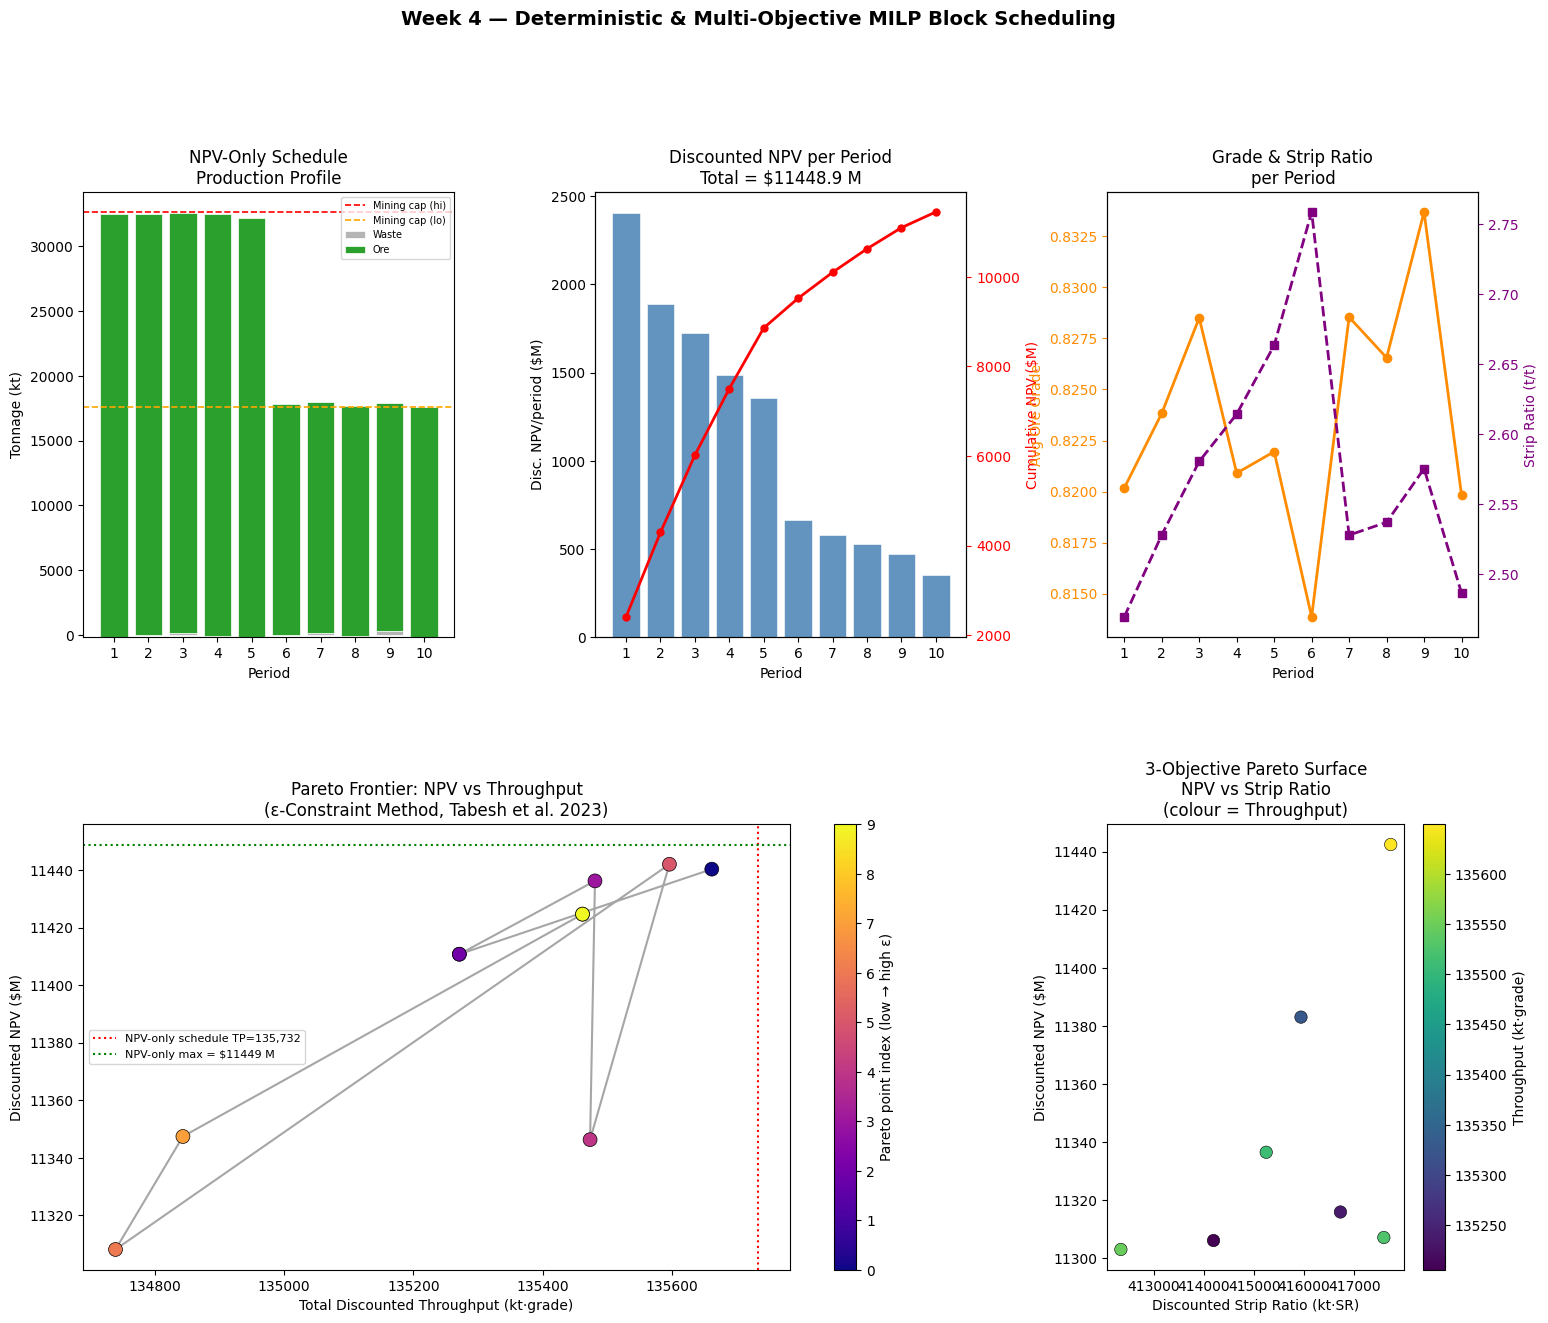

Figure saved: week4_moo_plots.png


In [ ]:
fig = plt.figure(figsize=(18, 14))
gs  = GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# ─── Plot 1: Production schedule (Gantt-style bar chart) ─────────────────────
ax1 = fig.add_subplot(gs[0, 0])
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, 10))

bar_waste    = period_kpi['tonnage_kt'] - period_kpi['throughput'] / period_kpi['avg_grade'].replace(0, np.nan)
bar_ore      = period_kpi['throughput'] / period_kpi['avg_grade'].replace(0, np.nan)

ax1.bar(period_kpi['period'], bar_waste.fillna(0),
        color='#b5b5b5', edgecolor='white', linewidth=0.5, label='Waste')
ax1.bar(period_kpi['period'], bar_ore.fillna(0),
        bottom=bar_waste.fillna(0),
        color='#2ca02c', edgecolor='white', linewidth=0.5, label='Ore')
ax1.axhline(MC_hi, color='red',    linestyle='--', linewidth=1.2, label='Mining cap (hi)')
ax1.axhline(MC_lo, color='orange', linestyle='--', linewidth=1.2, label='Mining cap (lo)')
ax1.set_xlabel('Period'); ax1.set_ylabel('Tonnage (kt)')
ax1.set_title('NPV-Only Schedule\nProduction Profile')
ax1.legend(fontsize=7); ax1.set_xticks(range(1, T+1))

# ─── Plot 2: Cumulative discounted NPV ────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(period_kpi['period'], period_kpi['disc_npv_M'],
        color='steelblue', edgecolor='white', linewidth=0.5, alpha=0.85)
ax2b = ax2.twinx()
ax2b.plot(period_kpi['period'], period_kpi['cum_disc_npv_M'],
          'r-o', linewidth=2, markersize=5, label='Cumulative NPV')
ax2.set_xlabel('Period'); ax2.set_ylabel('Disc. NPV/period ($M)')
ax2b.set_ylabel('Cumulative NPV ($M)', color='red')
ax2b.tick_params(axis='y', colors='red')
ax2.set_title(f'Discounted NPV per Period\nTotal = ${obj_npv:.1f} M')
ax2.set_xticks(range(1, T+1))

# ─── Plot 3: Average grade & strip ratio trajectory ──────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
color1, color2 = 'darkorange', 'purple'
ax3.plot(period_kpi['period'], period_kpi['avg_grade'], 'o-',
         color=color1, linewidth=2, markersize=6, label='Avg grade')
ax3.set_xlabel('Period'); ax3.set_ylabel('Avg Ore Grade', color=color1)
ax3.tick_params(axis='y', colors=color1)
ax3b = ax3.twinx()
ax3b.plot(period_kpi['period'], period_kpi['avg_sr'], 's--',
          color=color2, linewidth=2, markersize=6, label='Strip ratio')
ax3b.set_ylabel('Strip Ratio (t/t)', color=color2)
ax3b.tick_params(axis='y', colors=color2)
ax3.set_title('Grade & Strip Ratio\nper Period')
ax3.set_xticks(range(1, T+1))

# ─── Plot 4: NPV vs Throughput Pareto frontier ───────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
sc4 = ax4.scatter(pareto_df['throughput'], pareto_df['npv_M'],
                  c=pareto_df.index, cmap='plasma', s=100, zorder=5,
                  edgecolors='k', linewidths=0.5)
ax4.plot(pareto_df['throughput'], pareto_df['npv_M'],
         '-', color='gray', linewidth=1.5, zorder=4, alpha=0.7)
ax4.axvline(tp_npv_schedule, color='red', linestyle=':', linewidth=1.5,
            label=f'NPV-only schedule TP={tp_npv_schedule:,.0f}')
ax4.axhline(obj_npv, color='green', linestyle=':', linewidth=1.5,
            label=f'NPV-only max = ${obj_npv:.0f} M')
ax4.set_xlabel('Total Discounted Throughput (kt·grade)')
ax4.set_ylabel('Discounted NPV ($M)')
ax4.set_title('Pareto Frontier: NPV vs Throughput\n(ε-Constraint Method, Tabesh et al. 2023)')
ax4.legend(fontsize=8)
plt.colorbar(sc4, ax=ax4, label='Pareto point index (low → high ε)')

# ─── Plot 5: 3-objective — NPV vs SR coloured by throughput ──────────────────
ax5 = fig.add_subplot(gs[1, 2])
if len(pareto_3df) > 0:
    sc5 = ax5.scatter(pareto_3df['strip_ratio_disc'], pareto_3df['npv_M'],
                      c=pareto_3df['throughput'], cmap='viridis',
                      s=80, edgecolors='k', linewidths=0.4)
    plt.colorbar(sc5, ax=ax5, label='Throughput (kt·grade)')
    ax5.set_xlabel('Discounted Strip Ratio (kt·SR)')
    ax5.set_ylabel('Discounted NPV ($M)')
    ax5.set_title('3-Objective Pareto Surface\nNPV vs Strip Ratio\n(colour = Throughput)')
else:
    ax5.text(0.5, 0.5, 'No feasible\n3-obj points', ha='center', va='center',
             transform=ax5.transAxes, fontsize=12)

fig.suptitle('Week 4 — Deterministic & Multi-Objective MILP Block Scheduling',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('week4_moo_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: week4_moo_plots.png')


## 8. KPI Summary Table with Operational Interpretation

In [ ]:
# ── Build comprehensive KPI table ─────────────────────────────────────────────
npv_undiscounted = sched_npv['npv_exp'].sum()
throughput_total = sched_npv['throughput'].sum()
avg_grade_sched  = throughput_total / sched_npv['tonnage'].sum()
avg_sr_sched     = sched_npv['strip_ratio'].mean()
n_periods_full   = (period_kpi['tonnage_kt'] >= MC_lo).sum()

# Pareto frontier range
if len(pareto_df) > 1:
    npv_range_pct = (pareto_df['npv_M'].max() - pareto_df['npv_M'].min()) / pareto_df['npv_M'].max() * 100
    tp_range_pct  = (pareto_df['throughput'].max() - pareto_df['throughput'].min()) / pareto_df['throughput'].max() * 100
    pareto_pts    = len(pareto_df)
else:
    npv_range_pct = tp_range_pct = pareto_pts = 0

kpi_data = {
    'KPI': [
        'Total Discounted NPV',
        'Total Undiscounted NPV',
        'NPV Discounting Penalty',
        'Total Ore Throughput',
        'Average Ore Grade (sched.)',
        'Average Strip Ratio (sched.)',
        'Periods at Full Mining Capacity',
        'Solve Time (NPV-only MILP)',
        'Pareto Points (2-obj)',
        'NPV Trade-off Range (Pareto)',
        'Throughput Range (Pareto)',
        '3-Obj Pareto Surface Points',
    ],
    'Value': [
        f'${obj_npv:,.1f} M',
        f'${npv_undiscounted:,.1f} M',
        f'{(1 - obj_npv/npv_undiscounted)*100:.1f} % reduction',
        f'{throughput_total:,.0f} kt·grade',
        f'{avg_grade_sched:.3f} (fraction)',
        f'{avg_sr_sched:.2f} t waste / t ore',
        f'{n_periods_full} / {T}',
        f'{t_npv:.1f} s',
        f'{pareto_pts}',
        f'{npv_range_pct:.1f} % spread',
        f'{tp_range_pct:.1f} % spread',
        f'{len(pareto_3df)}',
    ],
    'Operational Interpretation': [
        'Present-value profit from mine over full 10-year life.',
        'Nominal (non-time-adjusted) total profit — 10 % discount erodes significant value.',
        'Value lost purely due to time-value-of-money; incentivises mining high-NPV blocks early.',
        'Total metal-bearing tonnage delivered to mill; drives mill utilisation and revenue.',
        'Higher grade = richer ore feed; target should stay within ±5 % of cut-off grade.',
        'kt waste moved per kt ore: lower is better; drives haulage cost and fleet size.',
        'Periods hitting ≥70 % of max capacity; gaps signal scheduling inflexibility.',
        'CBC solver at 1 % MIP gap; production-ready runs use HiGHS or Gurobi for tighter gaps.',
        'Points on NPV–Throughput Pareto front; shows decision space available to planners.',
        'Planners can trade this much NPV to gain maximum throughput flexibility.',
        'Range of achievable mill feed tonnages while staying mine-schedule feasible.',
        'Points on the 3-D NPV/Throughput/Strip-Ratio surface for ESG-aware scheduling.',
    ]
}

kpi_df = pd.DataFrame(kpi_data)
print('Week 4 — MILP Block Scheduling KPI Table')
print('=' * 110)
print(kpi_df.to_string(index=False))
print('=' * 110)


Week 4 — MILP Block Scheduling KPI Table
                            KPI                Value                                                               Operational Interpretation
           Total Discounted NPV          $11,448.9 M                                   Present-value profit from mine over full 10-year life.
         Total Undiscounted NPV          $17,036.3 M       Nominal (non-time-adjusted) total profit — 10 % discount erodes significant value.
        NPV Discounting Penalty     32.8 % reduction Value lost purely due to time-value-of-money; incentivises mining high-NPV blocks early.
           Total Ore Throughput     206,731 kt·grade      Total metal-bearing tonnage delivered to mill; drives mill utilisation and revenue.
     Average Ore Grade (sched.)     0.823 (fraction)         Higher grade = richer ore feed; target should stay within ±5 % of cut-off grade.
   Average Strip Ratio (sched.) 2.57 t waste / t ore          kt waste moved per kt ore: lower is better; d

## 9. Export Results

In [ ]:
# Save schedule
sched_npv.to_csv('week4_npv_schedule.csv', index=False)
print('Saved: week4_npv_schedule.csv')

# Save Pareto fronts
pareto_df.to_csv('week4_pareto_2obj.csv', index=False)
print('Saved: week4_pareto_2obj.csv')

if len(pareto_3df) > 0:
    pareto_3df.to_csv('week4_pareto_3obj.csv', index=False)
    print('Saved: week4_pareto_3obj.csv')

# Save KPI
kpi_df.to_csv('week4_kpi_table.csv', index=False)
print('Saved: week4_kpi_table.csv')

import pickle, json
week4_results = {
    'obj_npv_M'          : obj_npv,
    'solve_time_s'        : t_npv,
    'T'                   : T,
    'MC_lo'               : MC_lo,
    'MC_hi'               : MC_hi,
    'PC_lo'               : PC_lo,
    'PC_hi'               : PC_hi,
    'disc'                : disc.tolist(),
    'pareto_2obj_npv'     : pareto_df['npv_M'].tolist(),
    'pareto_2obj_tp'      : pareto_df['throughput'].tolist(),
}
with open('week4_results.json', 'w') as f:
    json.dump(week4_results, f, indent=2)
print('Saved: week4_results.json  (for Week 5 stochastic comparison)')

print('\n✓ Week 4 complete — ready for Week 5 stochastic MILP')


Saved: week4_npv_schedule.csv
Saved: week4_pareto_2obj.csv
Saved: week4_pareto_3obj.csv
Saved: week4_kpi_table.csv
Saved: week4_results.json  (for Week 5 stochastic comparison)

✓ Week 4 complete — ready for Week 5 stochastic MILP


## 10. Summary & Week 5 Preview

### What we built
| Stage | Method | Key output |
|-------|--------|-----------|
| 1 — Deterministic NPV | Binary MILP, CBC solver, 1% gap | Optimal schedule + \$M NPV |
| 2 — 2-Obj Pareto | ε-constraint on throughput | NPV vs Throughput trade-off curve |
| 3 — 3-Obj Pareto | Dual ε-constraint (TP + SR) | NPV / Throughput / Strip-Ratio surface |

### Precedence constraints follow Tabesh et al. (2023)
- Slope/precedence modelled via `slope_constraint` radius (50–150 m)
- Binary variable `y[b,t]` ensures each block is mined exactly once
- Per-period mining and processing capacity bounds enforced

### Week 5 — Stochastic Extension
The 200-scenario Monte Carlo matrix from Week 2 (`monte_carlo_matrices.npz`) will replace
the single `npv_expected` coefficient with a **sample-average approximation** (SAA) objective:

$$\max \; \frac{1}{S} \sum_{s=1}^{200} \sum_{t} \delta_t \sum_{b} \text{NPV}_{b,s} \, y_{b,t}$$

The key question: **does the deterministic optimal schedule remain optimal under grade uncertainty?**
